# Lab 2: Advanced VarNet — Multi-Slice, Multi-Contrast, Multi-Acceleration

In Lab 1 we explored a single-slice VarNet trained at a single acceleration factor. In this lab we investigate three extensions:

1. **Equispaced vs Random masks** — Does training with equispaced undersampling help when the test data is equispaced?
2. **Multi-acceleration training** — A single model jointly trained at 4x, 5x, and 6x acceleration.
3. **Neighbouring-slice reconstruction** — Feeding 3 adjacent slices (stacked on the coil dimension) so the model can exploit through-plane redundancy.
4. **Joint PD + PDFS contrast reconstruction** — Feeding both contrasts from the same exam so the model can share anatomical information across contrasts.

We compare all variants via SSIM on the test set.

## Part 0 — Setup

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

import torch
import numpy as np
import matplotlib.pyplot as plt
import h5py
import pandas as pd
from pathlib import Path
from collections import defaultdict

from models.varnet import SimpleVarNet
from utils.data import (
    FastMRIKneeDataset, MultiSliceDataset, PairedContrastDataset,
    collate_fn, paired_collate_fn,
)
from utils.transforms import RandomMaskFunc, EquispacedMaskFractionFunc
from utils.metrics import ssim_metric, SSIMLoss

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
print(f"PyTorch: {torch.__version__}")

# Paths
DATA_PATH = "/gpfs/scratch/johnsp23/DLrecon_lab1/data/knee"
SPLIT_CSV = "/gpfs/scratch/johnsp23/DLrecon_lab1/data/fastMRI_paired_knee.csv"
PRETRAINED = "/gpfs/scratch/johnsp23/DLrecon_lab1/pretrained"
RUNS = os.path.join(os.path.abspath(".."), "runs")

SKIP_SLICES = 4  # skip noisy edge slices for SSIM

Device: cuda
PyTorch: 2.1.0+cu118


In [2]:
# Helper: load a trained model from checkpoint
def load_model(checkpoint_path, device=device, use_dc=None):
    ckpt = torch.load(checkpoint_path, map_location="cpu")
    cfg = ckpt["config"]
    dc = cfg.get("use_dc", True) if use_dc is None else use_dc
    model = SimpleVarNet(
        num_cascades=cfg.get("num_cascades", 8),
        chans=cfg.get("chans", 18),
        pools=cfg.get("pools", 4),
        sens_chans=cfg.get("sens_chans", 8),
        sens_pools=cfg.get("sens_pools", 4),
        use_dc=dc,
        num_input_slices=cfg.get("num_input_slices", 1),
        num_coils=cfg.get("num_coils", 15),
        num_contrasts=cfg.get("num_contrasts", 1),
    )
    model.load_state_dict(ckpt["model_state_dict"])
    model.eval()
    return model.to(device), cfg

In [3]:
# How many volumes to evaluate per contrast (smaller = faster, larger = more accurate)
MAX_PD_VOLUMES = 10
MAX_PDFS_VOLUMES = 10
EVAL_BATCH_SIZE = 8


def limit_volumes(dataset, max_pd=MAX_PD_VOLUMES, max_pdfs=MAX_PDFS_VOLUMES, paired=False):
    """Filter dataset.examples in-place to first N PD and N PDFS volumes."""
    df = pd.read_csv(SPLIT_CSV)
    pd_set = set(df['pd'].dropna().tolist())
    pdfs_set = set(df['pdfs'].dropna().tolist())

    if paired:
        seen, kept = set(), []
        for ex in dataset.examples:
            pd_path = ex[0]
            if pd_path not in seen:
                if len(seen) >= max_pd:
                    continue
                seen.add(pd_path)
            kept.append(ex)
        dataset.examples = kept
    else:
        seen_pd, seen_pdfs, kept = set(), set(), []
        for ex in dataset.examples:
            base = os.path.basename(ex[0])
            if base in pd_set:
                if base not in seen_pd and len(seen_pd) >= max_pd:
                    continue
                seen_pd.add(base)
            elif base in pdfs_set:
                if base not in seen_pdfs and len(seen_pdfs) >= max_pdfs:
                    continue
                seen_pdfs.add(base)
            kept.append(ex)
        dataset.examples = kept
    return dataset


def group_examples_by_volume(dataset):
    """Return list of [example_indices] grouped by volume."""
    groups = defaultdict(list)
    for i, ex in enumerate(dataset.examples):
        groups[ex[0]].append(i)
    return list(groups.values())


@torch.no_grad()
def _eval_volume_batched(model, dataset, indices, batch_size, paired):
    """Run model on all slices of one volume in batches. Returns list of SSIMs."""
    items = [dataset[i] for i in indices]
    if paired:
        ksp = torch.stack([x[0] for x in items])
        msk = torch.stack([x[1] for x in items])
        tgt_pd = torch.stack([x[2] for x in items])
        tgt_pdfs = torch.stack([x[3] for x in items])
        pd_max = items[0][4]
        pdfs_max = items[0][5]
        slice_nums = [x[8] for x in items]
        nlf = items[0][9]
    else:
        ksp = torch.stack([x[0] for x in items])
        msk = torch.stack([x[1] for x in items])
        tgt = torch.stack([x[2] for x in items])
        max_val = items[0][3]
        slice_nums = [x[5] for x in items]
        nlf = items[0][6]

    ssims_pd, ssims_pdfs, ssims = [], [], []
    for start in range(0, len(items), batch_size):
        end = start + batch_size
        b_ksp = ksp[start:end].to(device)
        b_msk = msk[start:end].to(device)
        if paired:
            outs = model(b_ksp, b_msk, num_low_frequencies=int(nlf))
            outs = [o.cpu() for o in outs]
            for i in range(b_ksp.shape[0]):
                idx = start + i
                if slice_nums[idx] < SKIP_SLICES:
                    continue
                ssims_pd.append(ssim_metric(outs[0][i], tgt_pd[idx], max_value=pd_max))
                ssims_pdfs.append(ssim_metric(outs[1][i], tgt_pdfs[idx], max_value=pdfs_max))
        else:
            out = model(b_ksp, b_msk, num_low_frequencies=int(nlf)).cpu()
            for i in range(out.shape[0]):
                idx = start + i
                if slice_nums[idx] < SKIP_SLICES:
                    continue
                ssims.append(ssim_metric(out[i], tgt[idx], max_value=max_val))
    return (ssims_pd, ssims_pdfs) if paired else ssims


@torch.no_grad()
def evaluate(model, dataset, batch_size=EVAL_BATCH_SIZE, label=""):
    """Single-output volume-batched eval. Returns (mean, std, all_ssims)."""
    model.eval()
    all_ssims = []
    vol_groups = group_examples_by_volume(dataset)
    n_vols = len(vol_groups)
    for vi, vol_indices in enumerate(vol_groups):
        all_ssims.extend(_eval_volume_batched(model, dataset, vol_indices, batch_size, paired=False))
        print(f"\r  {label}{vi+1}/{n_vols} volumes", end="", flush=True)
    print()
    return np.mean(all_ssims), np.std(all_ssims), all_ssims


@torch.no_grad()
def evaluate_paired(model, dataset, batch_size=EVAL_BATCH_SIZE, label=""):
    """Dual-output volume-batched eval. Returns dict with PD/PDFS/combined SSIMs."""
    model.eval()
    all_pd, all_pdfs = [], []
    vol_groups = group_examples_by_volume(dataset)
    n_vols = len(vol_groups)
    for vi, vol_indices in enumerate(vol_groups):
        spd, spdfs = _eval_volume_batched(model, dataset, vol_indices, batch_size, paired=True)
        all_pd.extend(spd)
        all_pdfs.extend(spdfs)
        print(f"\r  {label}{vi+1}/{n_vols} volume pairs", end="", flush=True)
    print()
    return {
        "pd": (np.mean(all_pd), np.std(all_pd)),
        "pdfs": (np.mean(all_pdfs), np.std(all_pdfs)),
        "combined": (np.mean(all_pd + all_pdfs), np.std(all_pd + all_pdfs)),
    }

In [4]:
# Helper: visualize ground truth, reconstruction, and error map
def show_recon(gt, recon, ssim_val, title=""):
    error = np.abs(recon - gt)
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(gt, cmap="gray"); axes[0].set_title("Ground truth"); axes[0].axis("off")
    axes[1].imshow(recon, cmap="gray"); axes[1].set_title(f"Reconstruction (SSIM={ssim_val:.4f})"); axes[1].axis("off")
    axes[2].imshow(error * 2, cmap="hot"); axes[2].set_title("Error (2x)"); axes[2].axis("off")
    if title:
        fig.suptitle(title, fontsize=12)
    plt.tight_layout()
    plt.show()

---
## Part 1 — Equispaced vs Random Mask Training

In Lab 1, we trained a model with **random** undersampling masks and tested it on both random and equispaced masks. Now we have a model trained specifically with **equispaced** masks. Does mask-matched training improve SSIM on equispaced test data?

We compare:
- **Random-trained model** evaluated on equispaced 4x test masks
- **Equispaced-trained model** evaluated on equispaced 4x test masks

In [5]:
# Load both models
# Equispaced 4x: prefer your own Lab 1 homework checkpoint if you have it,
# otherwise fall back to the shared pretrained version
local_equi = os.path.join(RUNS, "equi4x", "best.pt")
shared_equi = os.path.join(PRETRAINED, "varnet_equispaced4x.pt")
equi_path = local_equi if os.path.exists(local_equi) else shared_equi
print(f"Loading equispaced 4x from: {equi_path}")

random4x_model, random4x_cfg = load_model(os.path.join(PRETRAINED, "varnet_random4x.pt"))
equi4x_model, equi4x_cfg = load_model(equi_path)

print(f"Random 4x model: {sum(p.numel() for p in random4x_model.parameters()):,} params")
print(f"Equispaced 4x model: {sum(p.numel() for p in equi4x_model.parameters()):,} params")

Loading equispaced 4x from: /gpfs/home/johnsp23/dl-mri-recon-lab/runs/equi4x/best.pt
Random 4x model: 52,842,182 params
Equispaced 4x model: 52,842,182 params


In [6]:
# Build equispaced 4x test set (limited to first N PD + N PDFS volumes)
equi4x_test_ds = FastMRIKneeDataset(
    data_path=DATA_PATH, split_csv=SPLIT_CSV, split="test",
    mask_type="equispaced", center_fractions=[0.08], accelerations=[4],
    use_seed=True,
)
limit_volumes(equi4x_test_ds, paired=False)
print(f"Equispaced 4x test set: {len(equi4x_test_ds)} slices "
      f"(limited to {MAX_PD_VOLUMES} PD + {MAX_PDFS_VOLUMES} PDFS volumes)")

Equispaced 4x test set: 707 slices (limited to 10 PD + 10 PDFS volumes)


In [7]:
# Evaluate both models on equispaced 4x test data
print("Evaluating random-trained model on equispaced 4x test masks...")
rand_on_equi_mean, rand_on_equi_std, _ = evaluate(random4x_model, equi4x_test_ds, label="random-trained: ")
print(f"  Random-trained:    SSIM = {rand_on_equi_mean:.4f} +/- {rand_on_equi_std:.4f}")

print("Evaluating equispaced-trained model on equispaced 4x test masks...")
equi_on_equi_mean, equi_on_equi_std, _ = evaluate(equi4x_model, equi4x_test_ds, label="equi-trained: ")
print(f"  Equispaced-trained: SSIM = {equi_on_equi_mean:.4f} +/- {equi_on_equi_std:.4f}")

print(f"\nDifference: {equi_on_equi_mean - rand_on_equi_mean:+.4f} SSIM")

Evaluating random-trained model on equispaced 4x test masks...


/gpfs/scratch/johnsp23/DLrecon_lab1/envs/varnet/lib/python3.11/site-packages/torch/nn/modules/conv.py:456: UserWarning: Applied workaround for CuDNN issue, install nvrtc.so (Triggered internally at ../aten/src/ATen/native/cudnn/Conv_v8.cpp:80.)
  return F.conv2d(input, weight, bias, self.stride,


  random-trained: 20/20 volumes
  Random-trained:    SSIM = 0.9298 +/- 0.0563
Evaluating equispaced-trained model on equispaced 4x test masks...
  equi-trained: 20/20 volumes
  Equispaced-trained: SSIM = 0.9310 +/- 0.0568

Difference: +0.0012 SSIM


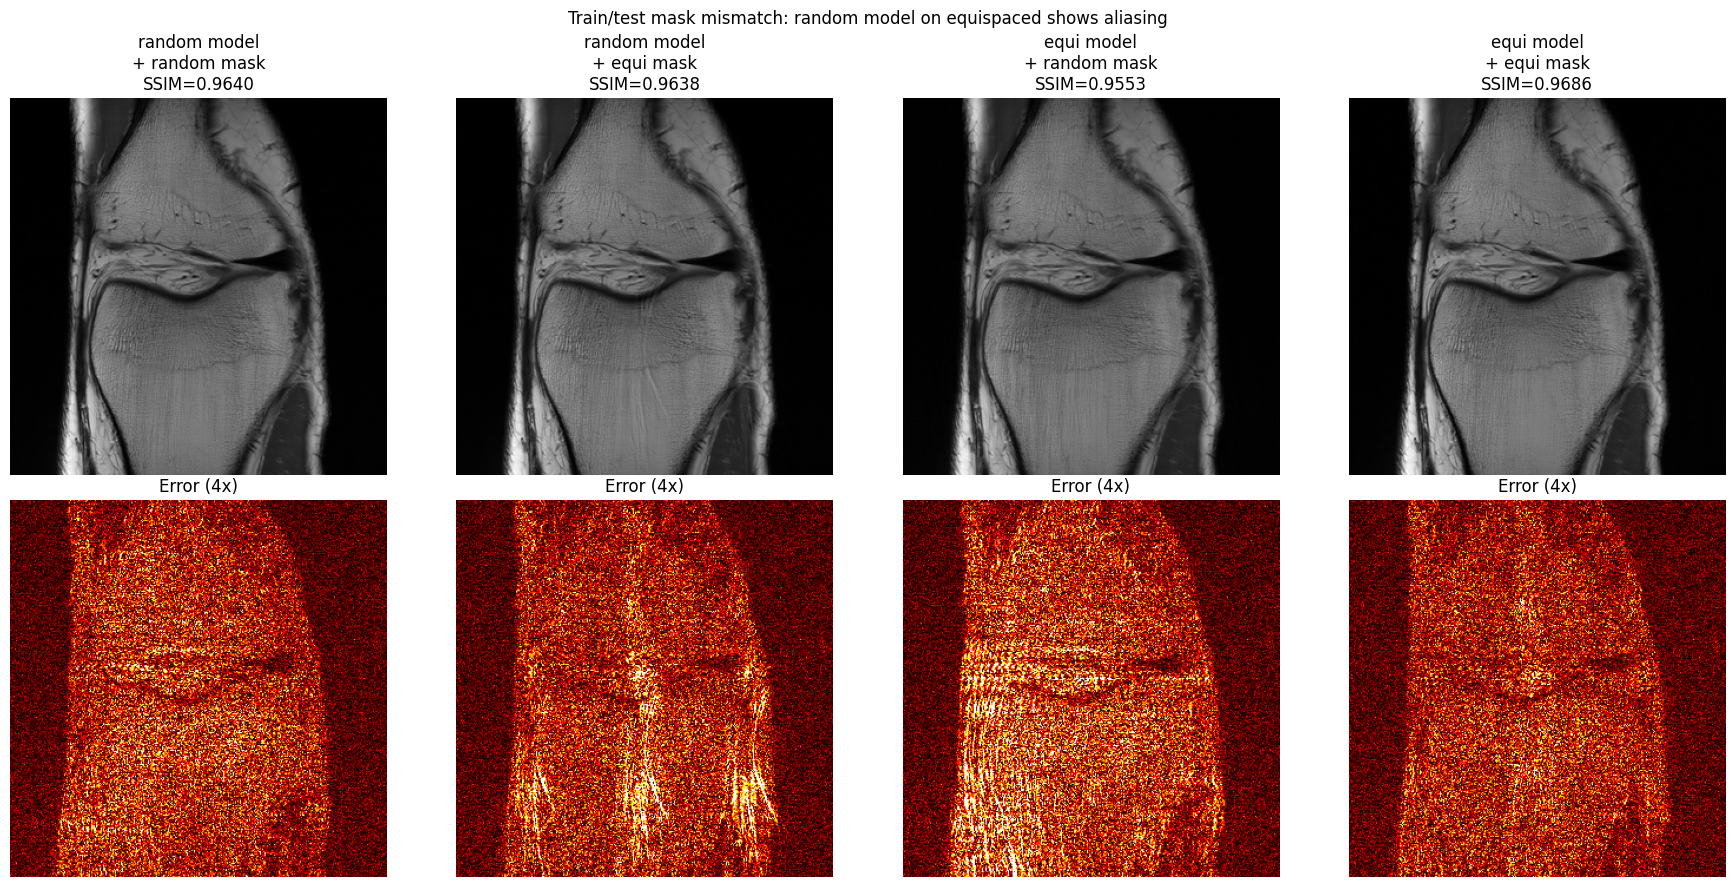

In [8]:
# Visual comparison: how does each model handle each mask type?
# This reproduces (and extends) Lab 1's finding that the random-trained
# model shows aliasing artifacts when given equispaced masks at test time.

from utils.transforms import to_tensor, apply_mask

# Load one mid-volume slice from the test set directly so we can apply both mask types
df = pd.read_csv(SPLIT_CSV)
test_pd_files = df.loc[df['pd_split'] == 'test', 'pd'].dropna().tolist()
example_path = os.path.join(DATA_PATH, test_pd_files[0])

with h5py.File(example_path, "r") as f:
    kspace_slice = f["kspace"][15]  # mid-volume slice
    target_slice = f["reconstruction_rss"][15]
    max_value = float(f.attrs["max"])

random_mf = RandomMaskFunc(center_fractions=[0.08], accelerations=[4])
equi_mf = EquispacedMaskFractionFunc(center_fractions=[0.08], accelerations=[4])

ksp = to_tensor(kspace_slice)
mk_r, mask_r, nlf_r = apply_mask(ksp, random_mf, seed=42)
mk_e, mask_e, nlf_e = apply_mask(ksp, equi_mf, seed=42)

@torch.no_grad()
def recon(model, mk, mask, nlf):
    out = model(mk.unsqueeze(0).to(device), mask.unsqueeze(0).to(device),
                num_low_frequencies=int(nlf))
    return out[0].cpu().numpy()

# 4 combinations: {random model, equi model} x {random mask, equi mask}
recons = [
    ("random model", "random mask", recon(random4x_model, mk_r, mask_r, nlf_r)),
    ("random model", "equi mask",   recon(random4x_model, mk_e, mask_e, nlf_e)),
    ("equi model",   "random mask", recon(equi4x_model,   mk_r, mask_r, nlf_r)),
    ("equi model",   "equi mask",   recon(equi4x_model,   mk_e, mask_e, nlf_e)),
]

target = torch.from_numpy(target_slice.astype(np.float32))
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
for col, (m_name, mask_name, r) in enumerate(recons):
    s = ssim_metric(torch.from_numpy(r), target, max_value=max_value)
    axes[0, col].imshow(r, cmap="gray")
    axes[0, col].set_title(f"{m_name}\n+ {mask_name}\nSSIM={s:.4f}")
    axes[0, col].axis("off")
    err = np.abs(r - target_slice)
    axes[1, col].imshow(err * 4, cmap="hot", vmax=target_slice.max()*0.15)
    axes[1, col].set_title("Error (4x)")
    axes[1, col].axis("off")

plt.suptitle("Train/test mask mismatch: random model on equispaced shows aliasing", fontsize=12)
plt.tight_layout()
plt.show()


### Question 1 (write your answer below)

Do we see an improvement in reconstruction quality when using the equispaced mask? Explain why. 

*Your answer here.*

---
## Part 2 — Multi-Acceleration Undersampling

So far, every model has been trained at a single acceleration factor (4x). But in practice, it could be helpful to support mutliple acceleration factors. Can a **single model** handle multiple accelerations?

We trained a model with masks randomly drawn from {4x, 5x, 6x} during training. Let's see how it performs at each individual acceleration factor.

### Visualize the three mask densities

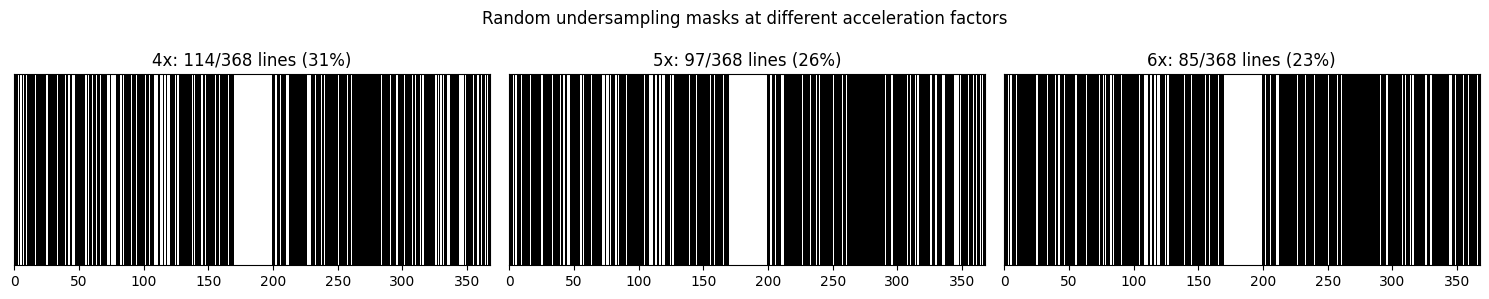

In [9]:
# Visualize random masks at 4x, 5x, and 6x
fig, axes = plt.subplots(1, 3, figsize=(15, 3))
for i, (accel, ax) in enumerate(zip([4, 5, 6], axes)):
    mf = RandomMaskFunc(center_fractions=[0.08], accelerations=[accel], seed=42)
    m, nlf = mf(shape=(1, 640, 368, 2))
    mask_1d = m[0, 0, :, 0].numpy()
    sampled = int(mask_1d.sum())
    ax.imshow(mask_1d.reshape(1, -1), cmap="gray", aspect="auto", interpolation="none")
    ax.set_title(f"{accel}x: {sampled}/{len(mask_1d)} lines ({100*sampled/len(mask_1d):.0f}%)")
    ax.set_yticks([])
plt.suptitle("Random undersampling masks at different acceleration factors", fontsize=12)
plt.tight_layout()
plt.show()

---
## Part 3 — Neighbouring-Slice Reconstruction

MRI volumes are 3D, but our baseline VarNet reconstructs each 2D slice independently. Adjacent slices are correlated. By feeding **3 adjacent slices** (stacked along the coil dimension: 15 coils x 3 slices = 45 channels), can the model exploit this redundancy?

Key design details:
- The **cascade U-Net** sees 3 images (slices) so it can learn cross-slice features.
- At the output, only the center slice is used to compute the loss
This model was jointly trained at 4x, 5x, and 6x acceleration.

In [10]:
# Load the multi-slice model
ms_model, ms_cfg = load_model(os.path.join(RUNS, "multislice_random_4x5x6x", "best.pt"))
print(f"Multi-slice model: {sum(p.numel() for p in ms_model.parameters()):,} params")
print(f"  num_input_slices = {ms_cfg.get('num_input_slices')}")
print(f"  accelerations = {ms_cfg.get('accelerations')}")

Multi-slice model: 52,853,750 params
  num_input_slices = 3
  accelerations = [4, 5, 6]


In [11]:
# Evaluate multi-slice model at each acceleration factor
ms_results = {}
for accel in [4, 5, 6]:
    ds = MultiSliceDataset(
        data_path=DATA_PATH, split_csv=SPLIT_CSV, split="test",
        mask_type="random", center_fractions=[0.08], accelerations=[accel],
        use_seed=True,
    )
    limit_volumes(ds, paired=False)
    mean_ssim, std_ssim, _ = evaluate(ms_model, ds, label=f"{accel}x: ")
    ms_results[accel] = (mean_ssim, std_ssim)
    print(f"  Multi-slice @ {accel}x: SSIM = {mean_ssim:.4f} +/- {std_ssim:.4f}")

  4x: 20/20 volumes
  Multi-slice @ 4x: SSIM = 0.9289 +/- 0.0555
  5x: 20/20 volumes
  Multi-slice @ 5x: SSIM = 0.9215 +/- 0.0582
  6x: 20/20 volumes
  Multi-slice @ 6x: SSIM = 0.9158 +/- 0.0596


In [ ]:
# Visual comparison: multi-slice vs single-slice baseline at 6x acceleration
# (the regime where cross-slice information should help the most)

# Load baseline model here so we can compare (also reused in Part 5)
if 'baseline_model' not in dir():
    baseline_model, baseline_cfg = load_model(os.path.join(RUNS, 'baseline_random_4x5x6x', 'best.pt'))

ACCEL_DEMO = 6

ds_ss = FastMRIKneeDataset(
    data_path=DATA_PATH, split_csv=SPLIT_CSV, split='test',
    mask_type='random', center_fractions=[0.08], accelerations=[ACCEL_DEMO],
    use_seed=True,
)
ds_ms_vis = MultiSliceDataset(
    data_path=DATA_PATH, split_csv=SPLIT_CSV, split='test',
    mask_type='random', center_fractions=[0.08], accelerations=[ACCEL_DEMO],
    use_seed=True,
)

# Pick the same volume + same slice for both datasets (mid-volume)
TARGET_SLICE = 15
ss_idx = next(i for i, ex in enumerate(ds_ss.examples) if ex[1] == TARGET_SLICE)
ss_fname = ds_ss.examples[ss_idx][0]
ms_idx = next(i for i, ex in enumerate(ds_ms_vis.examples)
              if ex[0] == ss_fname and ex[1] == TARGET_SLICE)

ss_ksp, ss_mask, ss_tgt, ss_mv, _, ss_sl, ss_nlf = ds_ss[ss_idx]
ms_ksp, ms_mask, ms_tgt, ms_mv, _, ms_sl, ms_nlf = ds_ms_vis[ms_idx]

with torch.no_grad():
    ss_recon = baseline_model(ss_ksp.unsqueeze(0).to(device), ss_mask.unsqueeze(0).to(device),
                              num_low_frequencies=int(ss_nlf))[0].cpu().numpy()
    ms_recon = ms_model(ms_ksp.unsqueeze(0).to(device), ms_mask.unsqueeze(0).to(device),
                        num_low_frequencies=int(ms_nlf))[0].cpu().numpy()

target_np = ss_tgt.numpy()
ss_ssim = ssim_metric(torch.from_numpy(ss_recon), ss_tgt, max_value=ss_mv)
ms_ssim = ssim_metric(torch.from_numpy(ms_recon), ms_tgt, max_value=ms_mv)
delta = ms_ssim - ss_ssim

ss_err = np.abs(ss_recon - target_np)
ms_err = np.abs(ms_recon - target_np)
err_max = max(ss_err.max(), ms_err.max()) * 0.6  # shared scale

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

axes[0, 0].imshow(target_np, cmap='gray');                axes[0, 0].set_title('Ground truth');             axes[0, 0].axis('off')
axes[0, 1].imshow(ss_recon, cmap='gray');                 axes[0, 1].set_title(f'Single-slice baseline\nSSIM={ss_ssim:.4f}');             axes[0, 1].axis('off')
axes[0, 2].imshow(ms_recon, cmap='gray');                 axes[0, 2].set_title(f'Multi-slice (3-slice)\nSSIM={ms_ssim:.4f}  (Δ={delta:+.4f})');             axes[0, 2].axis('off')

axes[1, 0].imshow(target_np, cmap='gray');                axes[1, 0].set_title('Ground truth');             axes[1, 0].axis('off')
axes[1, 1].imshow(ss_err, cmap='hot', vmax=err_max);      axes[1, 1].set_title(f'Single-slice error (mean={ss_err.mean():.5f})');             axes[1, 1].axis('off')
axes[1, 2].imshow(ms_err, cmap='hot', vmax=err_max);      axes[1, 2].set_title(f'Multi-slice error (mean={ms_err.mean():.5f})');             axes[1, 2].axis('off')

plt.suptitle(f'Multi-slice vs single-slice at {ACCEL_DEMO}x acceleration (slice {TARGET_SLICE})', fontsize=12)
plt.tight_layout()
plt.show()


### Question 2 (write your answer below)

Comment on the relative performance (SSIM). How could we further boost performance with the same 3- slice input?

*Your answer here.*

---
## Part 4 — Joint PD + PDFS Contrast Reconstruction

In the fastMRI knee dataset, each exam includes both a **PD** and a **PDFS** acquisition of the same anatomy. The underlying structure is the same (just the contrast weighting differs).
The joint-contrast model receives 6 images (3 slices of each contrast) and produces **two outputs**: the center-slice reconstruction for PD and PDFS separately. Enabling cross-slice AND cross-contrast feature learning.

This model was jointly trained at 4x, 5x, and 6x acceleration.

In [ ]:
# Load the joint-contrast model
jc_model, jc_cfg = load_model(os.path.join(RUNS, "joint_contrast_random_4x5x6x", "best.pt"))
print(f"Joint-contrast model: {sum(p.numel() for p in jc_model.parameters()):,} params")
print(f"  num_input_slices = {jc_cfg.get('num_input_slices')}")
print(f"  num_contrasts = {jc_cfg.get('num_contrasts')}")
print(f"  accelerations = {jc_cfg.get('accelerations')}")

In [ ]:
# Evaluate joint-contrast model at each acceleration factor
jc_results = {}
for accel in [4, 5, 6]:
    ds = PairedContrastDataset(
        data_path=DATA_PATH, split_csv=SPLIT_CSV, split="test",
        mask_type="random", center_fractions=[0.08], accelerations=[accel],
        use_seed=True,
    )
    limit_volumes(ds, paired=True)
    result = evaluate_paired(jc_model, ds, label=f"{accel}x: ")
    jc_results[accel] = result
    print(f"  Joint-contrast @ {accel}x:")
    print(f"    PD:   SSIM = {result['pd'][0]:.4f} +/- {result['pd'][1]:.4f}")
    print(f"    PDFS: SSIM = {result['pdfs'][0]:.4f} +/- {result['pdfs'][1]:.4f}")
    print(f"    Avg:  SSIM = {result['combined'][0]:.4f} +/- {result['combined'][1]:.4f}")

In [ ]:
# PD vs PDFS breakdown across accelerations
fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(3)
width = 0.35
pd_means = [jc_results[a]["pd"][0] for a in [4, 5, 6]]
pdfs_means = [jc_results[a]["pdfs"][0] for a in [4, 5, 6]]
ax.bar(x - width/2, pd_means, width, label="PD")
ax.bar(x + width/2, pdfs_means, width, label="PDFS")
ax.set_xlabel("Acceleration Factor")
ax.set_ylabel("SSIM")
ax.set_title("Joint-contrast model: PD vs PDFS SSIM by acceleration")
ax.set_xticks(x)
ax.set_xticklabels([f"{a}x" for a in [4, 5, 6]])
ax.legend()
ax.set_ylim(bottom=0.85)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# Visual comparison: joint-contrast model on a paired example at 4x
ds_vis = PairedContrastDataset(
    data_path=DATA_PATH, split_csv=SPLIT_CSV, split="test",
    mask_type="random", center_fractions=[0.08], accelerations=[4],
    use_seed=True,
)

# Find a mid-volume slice (skip edge slices)
sample = None
for ex_idx, (_, _, sl, _) in enumerate(ds_vis.examples):
    if sl >= 15:
        sample = ds_vis[ex_idx]
        break

(ksp, msk, tgt_pd, tgt_pdfs, pd_mv, pdfs_mv, _, _, sl, nlf) = sample
ksp_d = ksp.unsqueeze(0).to(device)
msk_d = msk.unsqueeze(0).to(device)

with torch.no_grad():
    outputs = jc_model(ksp_d, msk_d, num_low_frequencies=int(nlf))
    recon_pd = outputs[0].cpu()
    recon_pdfs = outputs[1].cpu()

ssim_pd = ssim_metric(recon_pd[0], tgt_pd, max_value=pd_mv)
ssim_pdfs = ssim_metric(recon_pdfs[0], tgt_pdfs, max_value=pdfs_mv)

show_recon(tgt_pd.numpy(), recon_pd[0].numpy(), ssim_pd,
           title=f"Joint-contrast: PD output (slice {sl})")
show_recon(tgt_pdfs.numpy(), recon_pdfs[0].numpy(), ssim_pdfs,
           title=f"Joint-contrast: PDFS output (slice {sl})")

### Question 3 (write your answer below)

The joint-contrast model has the same number of cascades and U-Net channels as the single-slice model, but processes 90 input channels (6 slices * 15 coils) instead of 15. How might we better leverage the additional input information?

*Your answer here.*

---
## Part 5 — SSIM Comparison Across All Models

For a fair comparison, all three models were trained with the same acceleration mix (4x/5x/6x random masks). The only difference is the input representation:

| Model | Input | Groups | U-Net channels |
|-------|-------|--------|---------------|
| **Baseline** | 1 slice, 1 contrast (15 coils) | 1 | 2 |
| **Multi-slice** | 3 slices, 1 contrast (45 coils) | 3 | 6 |
| **Joint-contrast** | 3 slices, 2 contrasts (90 coils) | 6 | 12 |

In [ ]:
# Load and evaluate single-slice baseline (trained at 4x/5x/6x) at each acceleration
baseline_model, baseline_cfg = load_model(os.path.join(RUNS, "baseline_random_4x5x6x", "best.pt"))
print(f"Baseline model: {sum(p.numel() for p in baseline_model.parameters()):,} params")

baseline_results = {}
for accel in [4, 5, 6]:
    ds = FastMRIKneeDataset(
        data_path=DATA_PATH, split_csv=SPLIT_CSV, split="test",
        mask_type="random", center_fractions=[0.08], accelerations=[accel],
        use_seed=True,
    )
    limit_volumes(ds, paired=False)
    mean_ssim, std_ssim, _ = evaluate(baseline_model, ds, label=f"{accel}x: ")
    baseline_results[accel] = (mean_ssim, std_ssim)
    print(f"  Baseline (4x/5x/6x) @ {accel}x: SSIM = {mean_ssim:.4f} +/- {std_ssim:.4f}")

In [ ]:
# Summary table
print("=" * 72)
print(f"{'Model':<30s} {'4x':>12s} {'5x':>12s} {'6x':>12s}")
print("=" * 72)

print(f"{'Baseline (single-slice)':<30s}", end="")
for accel in [4, 5, 6]:
    m, s = baseline_results[accel]
    print(f" {m:.4f}+/-{s:.3f}", end="")
print()

print(f"{'Multi-slice (3-slice)':<30s}", end="")
for accel in [4, 5, 6]:
    m, s = ms_results[accel]
    print(f" {m:.4f}+/-{s:.3f}", end="")
print()

print(f"{'Joint-contrast (PD+PDFS)':<30s}", end="")
for accel in [4, 5, 6]:
    m, s = jc_results[accel]["combined"]
    print(f" {m:.4f}+/-{s:.3f}", end="")
print()

print("=" * 72)
print()

# Improvement over baseline at each acceleration
print("Improvement over single-slice baseline (SSIM difference):")
print(f"{'':<30s} {'4x':>10s} {'5x':>10s} {'6x':>10s}")
print("-" * 62)
print(f"{'Multi-slice':<30s}", end="")
for accel in [4, 5, 6]:
    diff = ms_results[accel][0] - baseline_results[accel][0]
    print(f" {diff:+.4f}   ", end="")
print()
print(f"{'Joint-contrast':<30s}", end="")
for accel in [4, 5, 6]:
    diff = jc_results[accel]["combined"][0] - baseline_results[accel][0]
    print(f" {diff:+.4f}   ", end="")
print()

In [ ]:
# Bar chart comparison
accels = [4, 5, 6]
x = np.arange(len(accels))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 6))

baseline_means = [baseline_results[a][0] for a in accels]
ms_means = [ms_results[a][0] for a in accels]
jc_means = [jc_results[a]["combined"][0] for a in accels]

bars1 = ax.bar(x - width, baseline_means, width, label="Baseline (single-slice)")
bars2 = ax.bar(x, ms_means, width, label="Multi-slice (3-slice)")
bars3 = ax.bar(x + width, jc_means, width, label="Joint-contrast (PD+PDFS)")

ax.set_xlabel("Acceleration Factor")
ax.set_ylabel("SSIM")
ax.set_title("Test SSIM by Model and Acceleration Factor (all trained at 4x/5x/6x)")
ax.set_xticks(x)
ax.set_xticklabels([f"{a}x" for a in accels])
ax.legend()
ax.set_ylim(bottom=0.8)
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# Improvement-over-baseline chart: is the benefit larger at higher acceleration?
accels = [4, 5, 6]
x = np.arange(len(accels))
width = 0.35

ms_improvement = [ms_results[a][0] - baseline_results[a][0] for a in accels]
jc_improvement = [jc_results[a]["combined"][0] - baseline_results[a][0] for a in accels]

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(x - width/2, ms_improvement, width, label="Multi-slice")
ax.bar(x + width/2, jc_improvement, width, label="Joint-contrast")
ax.axhline(0, color="black", linewidth=0.8)

ax.set_xlabel("Acceleration Factor")
ax.set_ylabel("SSIM improvement over baseline")
ax.set_title("Benefit of richer input vs single-slice baseline")
ax.set_xticks(x)
ax.set_xticklabels([f"{a}x" for a in accels])
ax.legend()
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

---
### Question 4 (write your answer below)

Looking at the summary table and bar chart (all three models trained on the same 4x/5x/6x acceleration mix):

1. Does the multi-slice model improve over the single-slice baseline? At which acceleration factors is the improvement largest, and why?
2. Does joint-contrast reconstruction provide additional benefit beyond multi-slice? What might explain the relative performance of PD vs PDFS reconstruction?
3. All three models have the same number of cascades (12) and U-Net base channels (24), but the U-Net input channels differ (2 vs 6 vs 12). What are the trade-offs of increasing input channels while keeping the architecture fixed?

*Your answer here.*